# **Data Re-uploading y Quantum Neural Networks aplicado al conjunto de Iris**
## *Sebastián González Juárez*

DR-QNN multiclase en 1 qubit para Iris sin PCA

# **1. Imports, configuración global y reproducibilidad**

**Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

**Reproducibilidad**

In [2]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_default_dtype(torch.float64)

**Quantum device**

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE =", DEVICE)
print("Torch dtype =", torch.get_default_dtype())
print("PennyLane version =", qml.__version__)

DEVICE = cuda
Torch dtype = torch.float64
PennyLane version = 0.37.0


**Configuración del modelo**

In [4]:
N_QUBITS = 1
N_CLASES = 3
N_FEATURES = 3

# Número de capas de data re-uploading
N_LAYERS = 8

# Entrenamiento
EPOCHS = 50
LR_THETA = 0.05
LR_ALPHA = 0.03
WEIGHT_DECAY = 0.0

**Nombres de clases Iris**

In [5]:
NOMBRES_CLASES = [
    "setosa",
    "versicolor",
    "virginica"
]

**Device PennyLane**

In [6]:
dev = qml.device("default.qubit.torch", wires=N_QUBITS)

print("Configuración lista.")
print(f"N_QUBITS = {N_QUBITS}")
print(f"N_FEATURES = {N_FEATURES}")
print(f"N_CLASES = {N_CLASES}")
print(f"N_LAYERS = {N_LAYERS}")

Configuración lista.
N_QUBITS = 1
N_FEATURES = 3
N_CLASES = 3
N_LAYERS = 8


# **2. Carga de Iris, selección de 3 features y escalado angular**

**Cargar dataset Iris**

In [7]:
iris = load_iris()

X_raw = iris.data
y_raw = iris.target

print("Shape original X:", X_raw.shape)
print("Shape original y:", y_raw.shape)
print("Features originales:", iris.feature_names)
print("Clases:", iris.target_names)

Shape original X: (150, 4)
Shape original y: (150,)
Features originales: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: ['setosa' 'versicolor' 'virginica']


**Seleccionamos 3 features reales**

- 0: sepal length
- 2: petal length
- 3: petal width

In [8]:
FEATURE_IDXS = [0, 2, 3]

X = X_raw[:, FEATURE_IDXS]
y = y_raw.copy()

print("\nFeatures seleccionadas:")
for idx in FEATURE_IDXS:
    print(f"- {idx}: {iris.feature_names[idx]}")

print("\nShape X seleccionado:", X.shape)


Features seleccionadas:
- 0: sepal length (cm)
- 2: petal length (cm)
- 3: petal width (cm)

Shape X seleccionado: (150, 3)


Así tenemos x ∈ R^3 para cargarlo naturalmente en Rot.

**Split train / val / test estratificado**

In [9]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=SEED,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("\nTamaños:")
print("Train:", X_train_raw.shape, y_train.shape)
print("Val:  ", X_val_raw.shape, y_val.shape)
print("Test: ", X_test_raw.shape, y_test.shape)


Tamaños:
Train: (90, 3) (90,)
Val:   (30, 3) (30,)
Test:  (30, 3) (30,)


**Escalado angular**

In [10]:
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print("\nRangos después del escalado:")
print("Train min por feature:", X_train.min(axis=0))
print("Train max por feature:", X_train.max(axis=0))


Rangos después del escalado:
Train min por feature: [-3.14159265 -3.14159265 -3.14159265]
Train max por feature: [3.14159265 3.14159265 3.14159265]


**Pasar a tensores Torch**

In [11]:
X_train_t = torch.tensor(X_train, dtype=torch.float64, device=DEVICE)
X_val_t   = torch.tensor(X_val,   dtype=torch.float64, device=DEVICE)
X_test_t  = torch.tensor(X_test,  dtype=torch.float64, device=DEVICE)

y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
y_val_t   = torch.tensor(y_val,   dtype=torch.long, device=DEVICE)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=DEVICE)

print("\nTensores listos:")
print("X_train_t:", X_train_t.shape, X_train_t.dtype, X_train_t.device)
print("y_train_t:", y_train_t.shape, y_train_t.dtype, y_train_t.device)


Tensores listos:
X_train_t: torch.Size([90, 3]) torch.float64 cuda:0
y_train_t: torch.Size([90]) torch.int64 cuda:0


# 3. **Targets geométricos A, B, C en Bloch y Y_TARGETS**

**Base ortonormal del plano perpendicular a la diagonal (1,1,1) y así aprovechar las rotaciones**

In [12]:
u = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
v = np.array([1.0,  1.0, -2.0]) / np.sqrt(6.0)

**Tres vértices de un triángulo equilátero en la esfera de Bloch**

In [13]:
A = u
B = -0.5 * u + (np.sqrt(3.0) / 2.0) * v
C = -0.5 * u - (np.sqrt(3.0) / 2.0) * v

BLOCH_TARGETS_np = np.stack([A, B, C], axis=0)

print("BLOCH_TARGETS:")
print(BLOCH_TARGETS_np)

print("\nNormas:")
for i, vec in enumerate(BLOCH_TARGETS_np):
    print(f"||target {i}|| =", np.linalg.norm(vec))

print("\nProductos punto:")
for i in range(N_CLASES):
    for j in range(i + 1, N_CLASES):
        print(f"target {i} · target {j} =", np.dot(BLOCH_TARGETS_np[i], BLOCH_TARGETS_np[j]))

BLOCH_TARGETS:
[[ 7.07106781e-01 -7.07106781e-01  0.00000000e+00]
 [ 5.55111512e-17  7.07106781e-01 -7.07106781e-01]
 [-7.07106781e-01 -5.55111512e-17  7.07106781e-01]]

Normas:
||target 0|| = 0.9999999999999999
||target 1|| = 1.0
||target 2|| = 1.0

Productos punto:
target 0 · target 1 = -0.4999999999999999
target 0 · target 2 = -0.49999999999999983
target 1 · target 2 = -0.5000000000000001


**Matriz de fidelidades ideales**

Para estados puros de 1 qubit:
- $F_ij = (1 + r_i · r_j) / 2$ y Como $r_i · r_j = -1/2$ para $i != j: F_ij = 1/4$

In [14]:
Y_TARGETS_np = 0.5 * (1.0 + BLOCH_TARGETS_np @ BLOCH_TARGETS_np.T)

print("\nY_TARGETS_np:")
print(Y_TARGETS_np)


Y_TARGETS_np:
[[1.   0.25 0.25]
 [0.25 1.   0.25]
 [0.25 0.25 1.  ]]


**Pasar a tensores Torch**

In [15]:
BLOCH_TARGETS = torch.tensor(
    BLOCH_TARGETS_np,
    dtype=torch.float64,
    device=DEVICE
)

Y_TARGETS = torch.tensor(
    Y_TARGETS_np,
    dtype=torch.float64,
    device=DEVICE
)

print("\nBLOCH_TARGETS tensor:", BLOCH_TARGETS.shape, BLOCH_TARGETS.dtype, BLOCH_TARGETS.device)
print("Y_TARGETS tensor:", Y_TARGETS.shape, Y_TARGETS.dtype, Y_TARGETS.device)


BLOCH_TARGETS tensor: torch.Size([3, 3]) torch.float64 cuda:0
Y_TARGETS tensor: torch.Size([3, 3]) torch.float64 cuda:0


# **4. Conversión Bloch → Ket objetivo**

**Para un vector de Bloch:**

**r** = (x, y, z), con **θ** = arccos(z) y **φ** = atan2(y, x), el estado cuántico es **|ψ(r)⟩** = cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩.

In [16]:
def bloch_to_ket(r):

    x, y, z = r

    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.arctan2(y, x)

    ket = np.array([
        np.cos(theta / 2),
        np.exp(1j * phi) * np.sin(theta / 2)
    ], dtype=np.complex128)

    ket /= np.linalg.norm(ket)

    return ket

**Estados objetivo**

In [17]:
ket_A = bloch_to_ket(A)
ket_B = bloch_to_ket(B)
ket_C = bloch_to_ket(C)

TARGET_STATES_np = np.stack(
    [ket_A, ket_B, ket_C],
    axis=0
)

print("TARGET_STATES shape:", TARGET_STATES_np.shape)

TARGET_STATES shape: (3, 2)


**Verificación de fidelidades**

In [18]:
print("\nFidelidades entre estados objetivo:")

for i in range(N_CLASES):
    for j in range(N_CLASES):

        F = np.abs(
            np.vdot(
                TARGET_STATES_np[i],
                TARGET_STATES_np[j]
            )
        )**2

        print(f"F({i},{j}) = {F:.6f}", end="    ")

    print()


Fidelidades entre estados objetivo:
F(0,0) = 1.000000    F(0,1) = 0.250000    F(0,2) = 0.250000    
F(1,0) = 0.250000    F(1,1) = 1.000000    F(1,2) = 0.250000    
F(2,0) = 0.250000    F(2,1) = 0.250000    F(2,2) = 1.000000    


**Tensor complejo para Torch**

In [19]:
TARGET_STATES = torch.tensor(
    TARGET_STATES_np,
    dtype=torch.complex128,
    device=DEVICE
)

print("\nTARGET_STATES:")
print(TARGET_STATES.shape)
print(TARGET_STATES.dtype)
print(TARGET_STATES.device)


TARGET_STATES:
torch.Size([3, 2])
torch.complex128
cuda:0


# **5. Circuito DR-QNN 1 qubit y modelo Torch**

**QNode**: Data re-uploading 1 qubit. 

**Entrada**: `x` (tensor shape (3,)), `theta` (tensor shape (N_LAYERS, 3)). 

**Salida**: estado final `|ψ(x)⟩` (tensor shape (2,)).

In [20]:
@qml.qnode(dev, interface="torch", diff_method="backprop")
def dr_qnn_state(x, theta):

    for l in range(N_LAYERS):

        # Data re-uploading: cargamos las 3 features como Rot
        qml.Rot(x[0], x[1], x[2], wires=0)

        # Procesamiento entrenable
        qml.Rot(theta[l, 0], theta[l, 1], theta[l, 2], wires=0)

    return qml.state()

**Modelo Torch**

In [21]:
class DRQNNWeightedFidelity(nn.Module):

    def __init__(self, n_layers=N_LAYERS):
        super().__init__()

        self.n_layers = n_layers

        # Parámetros cuánticos θ_l ∈ R^3
        self.theta = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                3,
                dtype=torch.float64,
                device=DEVICE
            )
        )

        # Pesos clásicos α_c de la weighted fidelity
        # Usamos raw_alpha y softplus para mantener α_c > 0
        self.raw_alpha = nn.Parameter(
            torch.zeros(
                N_CLASES,
                dtype=torch.float64,
                device=DEVICE
            )
        )

    def alpha(self):
        return torch.nn.functional.softplus(self.raw_alpha) + 1e-8

    def forward_state(self, x):
        return dr_qnn_state(x, self.theta)

    def fidelities_one(self, x):
        """
        Devuelve:
            F = [F_A, F_B, F_C]
        donde:
            F_c = |<target_c | ψ(x)>|^2
        """

        psi = self.forward_state(x)

        overlaps = torch.matmul(
            torch.conj(TARGET_STATES),
            psi
        )

        F = torch.abs(overlaps) ** 2

        return F

    def fidelities_batch(self, X):
        """
        X: shape (N, 3)

        Devuelve:
            F_all: shape (N, 3)
        """

        F_list = []

        for i in range(X.shape[0]):
            F_list.append(self.fidelities_one(X[i]))

        return torch.stack(F_list, dim=0)

    def logits(self, X):
        """
        Predicción por:
            score_c = alpha_c * F_c
        """

        F = self.fidelities_batch(X)
        scores = F * self.alpha().unsqueeze(0)

        return scores

    def predict(self, X):
        scores = self.logits(X)
        return torch.argmax(scores, dim=1)

# **6. Loss weighted fidelity y métricas**

**Loss que usaremos**: $χ²_wf = 1/2 Σ_{μ,c} (α_c F_c(x_μ) - Y_c(x_μ))²$, donde para cada muestra $μ, Y_c(x_μ)$ es la fila de $Y_TARGETS$ correspondiente a su clase verdadera.

In [22]:
def weighted_fidelity_loss(model, X, y):
    F = model.fidelities_batch(X)              # shape (N, 3)
    alpha = model.alpha().unsqueeze(0)         # shape (1, 3)

    scores = alpha * F                         # α_c F_c(x)

    Y_batch = Y_TARGETS[y]                     # shape (N, 3)

    loss = 0.5 * torch.mean((scores - Y_batch) ** 2)

    return loss


@torch.no_grad()
def accuracy(model, X, y):
    y_pred = model.predict(X)
    acc = (y_pred == y).double().mean().item()
    return acc


@torch.no_grad()
def get_predictions(model, X):
    return model.predict(X).detach().cpu().numpy()


@torch.no_grad()
def get_fidelities(model, X):
    return model.fidelities_batch(X).detach().cpu().numpy()


@torch.no_grad()
def get_scores(model, X):
    F = model.fidelities_batch(X)
    scores = F * model.alpha().unsqueeze(0)
    return scores.detach().cpu().numpy()

# **7. Inicialización del modelo, optimizador y entrenamiento**

**Crear modelo**

In [23]:
model = DRQNNWeightedFidelity(
    n_layers=N_LAYERS
).to(DEVICE)

print(model)
print("\nAlpha inicial:", model.alpha().detach().cpu().numpy())

DRQNNWeightedFidelity()

Alpha inicial: [0.69314719 0.69314719 0.69314719]


**Optimizador**

Usamos dos learning rates:
- theta: parámetros cuánticos
- raw_alpha: pesos clásicos de fidelidad

In [24]:
optimizer = optim.Adam(
    [
        {"params": [model.theta], "lr": LR_THETA},
        {"params": [model.raw_alpha], "lr": LR_ALPHA},
    ],
    weight_decay=WEIGHT_DECAY
)

**Historial**

In [25]:
history = {
    "loss_train": [],
    "loss_val": [],
    "acc_train": [],
    "acc_val": [],
    "alpha": []
}

**Entrenamiento**

In [26]:
for epoch in range(1, EPOCHS + 1):

    model.train()

    optimizer.zero_grad()

    loss_train = weighted_fidelity_loss(
        model,
        X_train_t,
        y_train_t
    )

    loss_train.backward()
    optimizer.step()

    # Métricas

    model.eval()

    with torch.no_grad():

        loss_val = weighted_fidelity_loss(
            model,
            X_val_t,
            y_val_t
        )

        acc_train = accuracy(
            model,
            X_train_t,
            y_train_t
        )

        acc_val = accuracy(
            model,
            X_val_t,
            y_val_t
        )

        alpha_now = model.alpha().detach().cpu().numpy()

    history["loss_train"].append(loss_train.item())
    history["loss_val"].append(loss_val.item())
    history["acc_train"].append(acc_train)
    history["acc_val"].append(acc_val)
    history["alpha"].append(alpha_now)

    # Print

    if epoch == 1 or epoch % 1 == 0 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:04d} | "
            f"Loss train = {loss_train.item():.6f} | "
            f"Loss val = {loss_val.item():.6f} | "
            f"Acc train = {acc_train:.4f} | "
            f"Acc val = {acc_val:.4f} | "
            f"alpha = {alpha_now}"
        )

print("\nEntrenamiento terminado.")
print("Alpha final:", model.alpha().detach().cpu().numpy())

Epoch 0001 | Loss train = 0.113733 | Loss val = 0.099137 | Acc train = 0.2778 | Acc val = 0.3000 | alpha = [0.70825966 0.67825971 0.67825972]
Epoch 0002 | Loss train = 0.098430 | Loss val = 0.089085 | Acc train = 0.5000 | Acc val = 0.3667 | alpha = [0.72296717 0.66683825 0.66492279]
Epoch 0003 | Loss train = 0.082437 | Loss val = 0.081414 | Acc train = 0.5444 | Acc val = 0.4333 | alpha = [0.73802438 0.66657878 0.65563412]
Epoch 0004 | Loss train = 0.073176 | Loss val = 0.078568 | Acc train = 0.5444 | Acc val = 0.4000 | alpha = [0.75351485 0.67295752 0.65183583]
Epoch 0005 | Loss train = 0.071800 | Loss val = 0.078442 | Acc train = 0.5444 | Acc val = 0.4667 | alpha = [0.76917883 0.68235713 0.65140373]
Epoch 0006 | Loss train = 0.073011 | Loss val = 0.078520 | Acc train = 0.5000 | Acc val = 0.4333 | alpha = [0.78489823 0.69352266 0.65184318]
Epoch 0007 | Loss train = 0.072822 | Loss val = 0.077954 | Acc train = 0.4889 | Acc val = 0.4333 | alpha = [0.80059997 0.70591375 0.65245536]
Epoch 

# **8. Evaluación final: accuracy, predicciones y matrices de confusión**

**Evaluación**

In [27]:
model.eval()

DRQNNWeightedFidelity()

**Accuracies finales**

In [28]:
acc_train_final = accuracy(model, X_train_t, y_train_t)
acc_val_final   = accuracy(model, X_val_t, y_val_t)
acc_test_final  = accuracy(model, X_test_t, y_test_t)

print("Accuracy final:")
print(f"Train = {acc_train_final:.4f}")
print(f"Val   = {acc_val_final:.4f}")
print(f"Test  = {acc_test_final:.4f}")

print("\nAlpha final:")
print(model.alpha().detach().cpu().numpy())

Accuracy final:
Train = 0.8000
Val   = 0.6000
Test  = 0.7333

Alpha final:
[0.80992766 1.17320907 0.99091498]


**Predicciones y matrices de confusión**

In [29]:
y_train_pred = get_predictions(model, X_train_t)
y_val_pred   = get_predictions(model, X_val_t)
y_test_pred  = get_predictions(model, X_test_t)

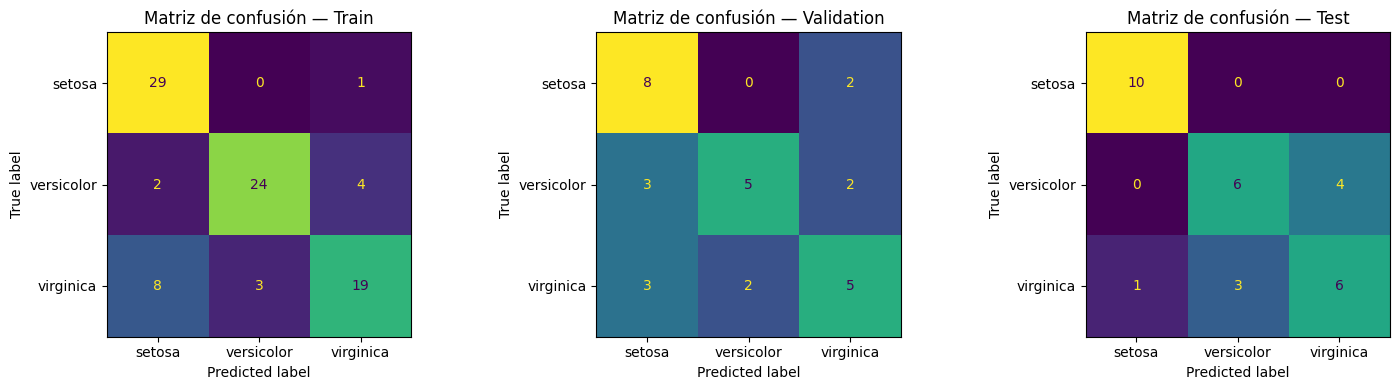

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_val, y_test],
    [y_train_pred, y_val_pred, y_test_pred],
    ["Train", "Validation", "Test"]
):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=NOMBRES_CLASES
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(f"Matriz de confusión — {title}")

plt.tight_layout()
plt.show()

**Curvas de entrenamiento**

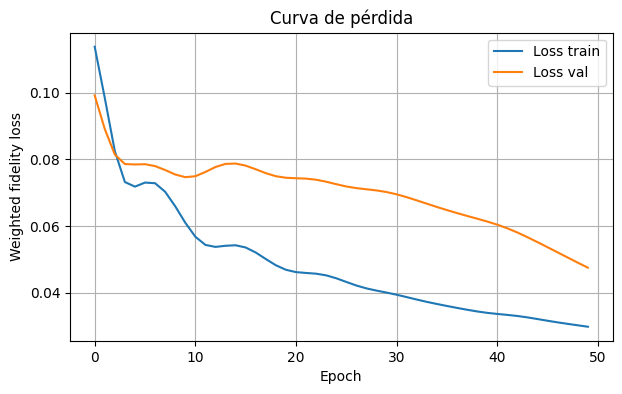

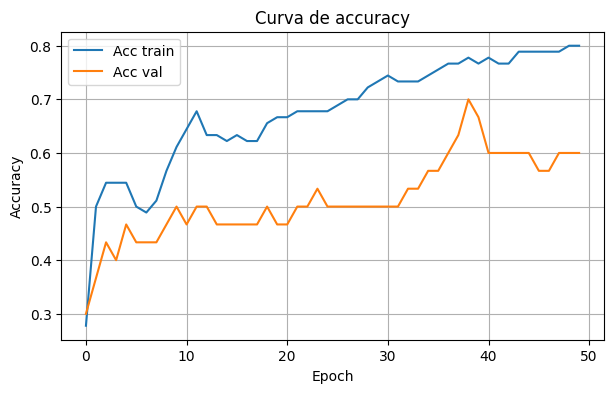

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(history["loss_train"], label="Loss train")
plt.plot(history["loss_val"], label="Loss val")
plt.xlabel("Epoch")
plt.ylabel("Weighted fidelity loss")
plt.title("Curva de pérdida")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["acc_train"], label="Acc train")
plt.plot(history["acc_val"], label="Acc val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curva de accuracy")
plt.legend()
plt.grid(True)
plt.show()

# **9. Fidelidades medias por clase**

**Fidelidades y scores en test**

In [33]:
F_test = get_fidelities(model, X_test_t)
S_test = get_scores(model, X_test_t)

print("Fidelidades medias por clase verdadera — TEST\n")

for clase_id, nombre in enumerate(NOMBRES_CLASES):
    mask = y_test == clase_id

    F_mean = F_test[mask].mean(axis=0)
    S_mean = S_test[mask].mean(axis=0)

    print(f"Clase verdadera: {nombre}")
    print("  Media F_A, F_B, F_C =", np.round(F_mean, 4))
    print("  Media αF_A, αF_B, αF_C =", np.round(S_mean, 4))
    print("  Target esperado =", np.round(Y_TARGETS_np[clase_id], 4))
    print()

Fidelidades medias por clase verdadera — TEST

Clase verdadera: setosa
  Media F_A, F_B, F_C = [0.9433 0.2324 0.3243]
  Media αF_A, αF_B, αF_C = [0.764  0.2727 0.3213]
  Target esperado = [1.   0.25 0.25]

Clase verdadera: versicolor
  Media F_A, F_B, F_C = [0.4208 0.5974 0.4818]
  Media αF_A, αF_B, αF_C = [0.3408 0.7009 0.4774]
  Target esperado = [0.25 1.   0.25]

Clase verdadera: virginica
  Media F_A, F_B, F_C = [0.4306 0.4862 0.5832]
  Media αF_A, αF_B, αF_C = [0.3487 0.5704 0.578 ]
  Target esperado = [0.25 0.25 1.  ]



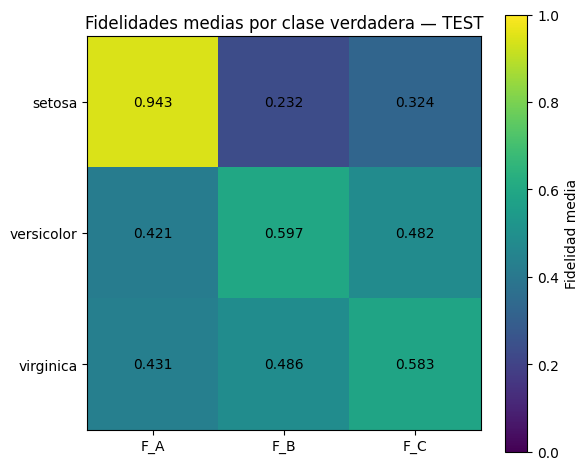

In [34]:
F_mean_matrix = np.zeros((N_CLASES, N_CLASES))

for clase_id in range(N_CLASES):
    mask = y_test == clase_id
    F_mean_matrix[clase_id] = F_test[mask].mean(axis=0)

plt.figure(figsize=(6, 5))
plt.imshow(F_mean_matrix, vmin=0, vmax=1)
plt.colorbar(label="Fidelidad media")

plt.xticks(range(N_CLASES), ["F_A", "F_B", "F_C"])
plt.yticks(range(N_CLASES), NOMBRES_CLASES)

plt.title("Fidelidades medias por clase verdadera — TEST")

for i in range(N_CLASES):
    for j in range(N_CLASES):
        plt.text(
            j, i,
            f"{F_mean_matrix[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# **10. Visualización Bloch de los estados transformados**

**QNode auxiliar**: devuelve `r(x) = (⟨X⟩, ⟨Y⟩, ⟨Z⟩)` usando los `theta` entrenados.

In [35]:
@qml.qnode(dev, interface="torch", diff_method="backprop")
def dr_qnn_bloch(x, theta):

    for l in range(N_LAYERS):

        qml.Rot(x[0], x[1], x[2], wires=0)
        qml.Rot(theta[l, 0], theta[l, 1], theta[l, 2], wires=0)

    return [
        qml.expval(qml.PauliX(0)),
        qml.expval(qml.PauliY(0)),
        qml.expval(qml.PauliZ(0))
    ]


@torch.no_grad()
def bloch_batch(model, X):

    points = []

    for i in range(X.shape[0]):

        r = dr_qnn_bloch(
            X[i],
            model.theta
        )

        r = torch.stack(r)
        points.append(r)

    return torch.stack(points).detach().cpu().numpy()

**Obtener puntos Bloch para train / val / test**

In [36]:
bloch_train = bloch_batch(model, X_train_t)
bloch_val   = bloch_batch(model, X_val_t)
bloch_test  = bloch_batch(model, X_test_t)

print("bloch_train:", bloch_train.shape)
print("bloch_val:  ", bloch_val.shape)
print("bloch_test: ", bloch_test.shape)

bloch_train: (90, 3)
bloch_val:   (30, 3)
bloch_test:  (30, 3)


**Visualización 3D**

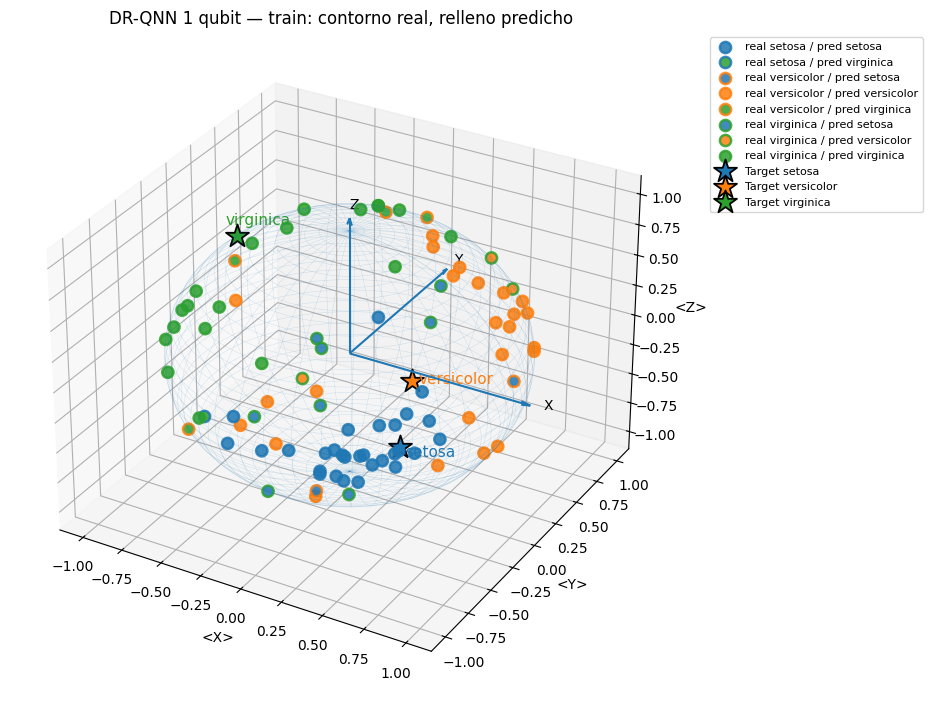

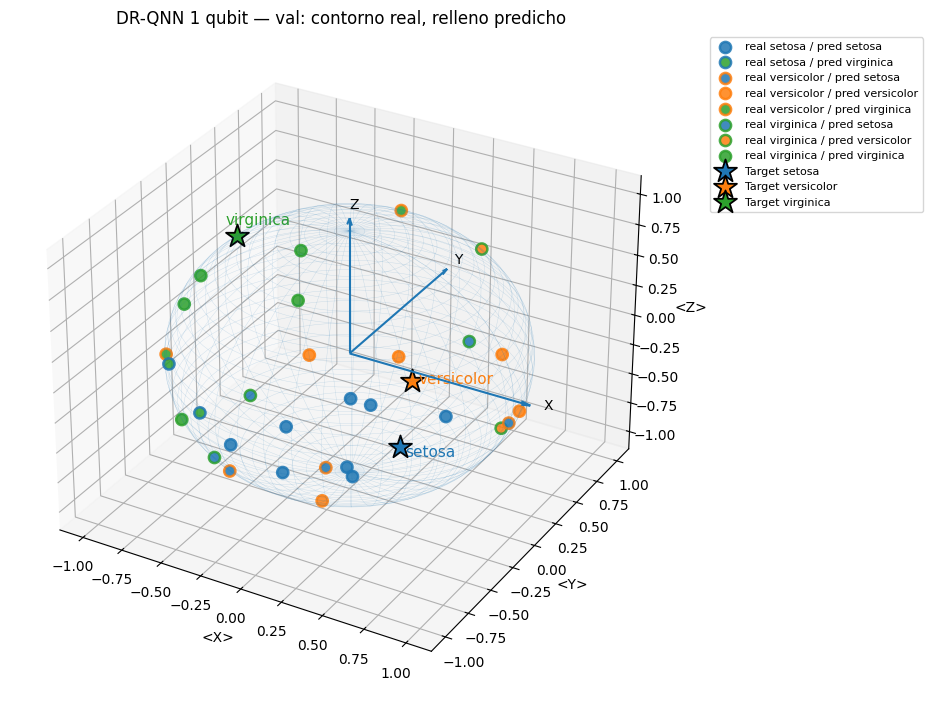

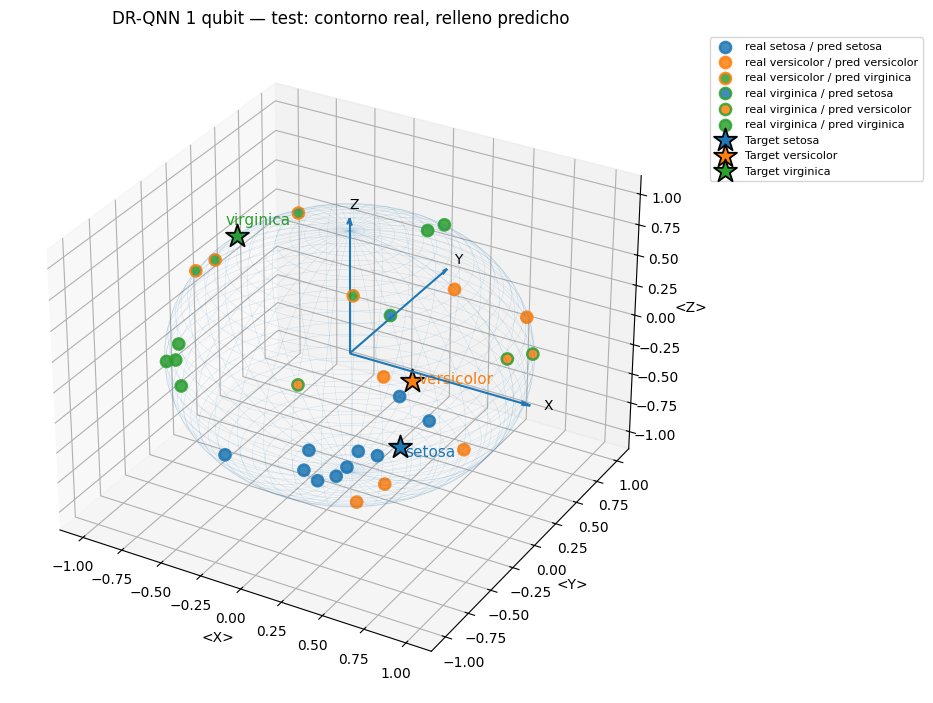

In [43]:
class_colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green"
}

def plot_bloch_3d_true_pred(bloch_points, y_true, y_pred, split_name):
    
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Esfera de Bloch
    phi = np.linspace(0, 2 * np.pi, 80)
    theta_s = np.linspace(0, np.pi, 40)

    xs = np.outer(np.cos(phi), np.sin(theta_s))
    ys = np.outer(np.sin(phi), np.sin(theta_s))
    zs = np.outer(np.ones_like(phi), np.cos(theta_s))

    ax.plot_wireframe(xs, ys, zs, linewidth=0.3, alpha=0.20)

    # Puntos: borde = real, relleno = predicho
    for true_id in range(N_CLASES):
        for pred_id in range(N_CLASES):

            mask = (y_true == true_id) & (y_pred == pred_id)

            if np.sum(mask) == 0:
                continue

            ax.scatter(
                bloch_points[mask, 0],
                bloch_points[mask, 1],
                bloch_points[mask, 2],
                s=65,
                facecolors=class_colors[pred_id],
                edgecolors=class_colors[true_id],
                linewidth=1.8,
                alpha=0.85,
                label=f"real {NOMBRES_CLASES[true_id]} / pred {NOMBRES_CLASES[pred_id]}"
            )

    # Targets
    for clase_id, nombre in enumerate(NOMBRES_CLASES):

        target = BLOCH_TARGETS_np[clase_id]

        ax.scatter(
            target[0],
            target[1],
            target[2],
            s=300,
            marker="*",
            color=class_colors[clase_id],
            edgecolor="black",
            linewidth=1.3,
            label=f"Target {nombre}"
        )

        ax.text(
            target[0] * 1.10,
            target[1] * 1.10,
            target[2] * 1.10,
            nombre,
            fontsize=11,
            color=class_colors[clase_id]
        )

    # Ejes
    ax.quiver(0, 0, 0, 1.1, 0, 0, arrow_length_ratio=0.05)
    ax.quiver(0, 0, 0, 0, 1.1, 0, arrow_length_ratio=0.05)
    ax.quiver(0, 0, 0, 0, 0, 1.1, arrow_length_ratio=0.05)

    ax.text(1.18, 0, 0, "X")
    ax.text(0, 1.18, 0, "Y")
    ax.text(0, 0, 1.18, "Z")

    ax.set_xlim([-1.15, 1.15])
    ax.set_ylim([-1.15, 1.15])
    ax.set_zlim([-1.15, 1.15])

    ax.set_xlabel("<X>")
    ax.set_ylabel("<Y>")
    ax.set_zlabel("<Z>")

    ax.set_title(f"DR-QNN 1 qubit — {split_name}: contorno real, relleno predicho")

    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), fontsize=8)
    plt.tight_layout()
    plt.show()


plot_bloch_3d_true_pred(bloch_train, y_train, y_train_pred, "train")
plot_bloch_3d_true_pred(bloch_val,   y_val,   y_val_pred,   "val")
plot_bloch_3d_true_pred(bloch_test,  y_test,  y_test_pred,  "test")

**Visualización 2D en el plano de los targets**

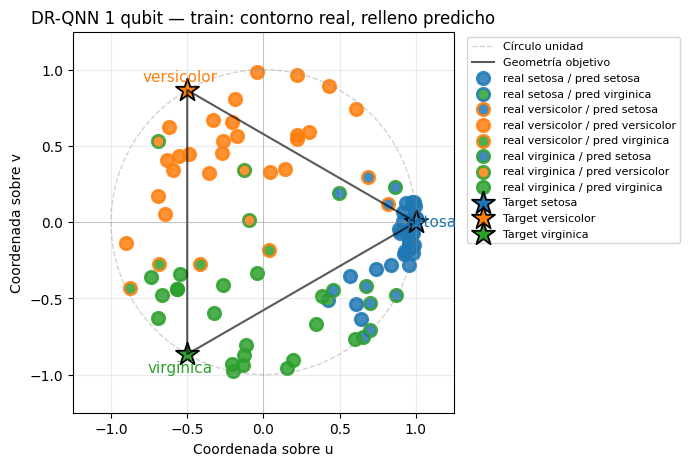

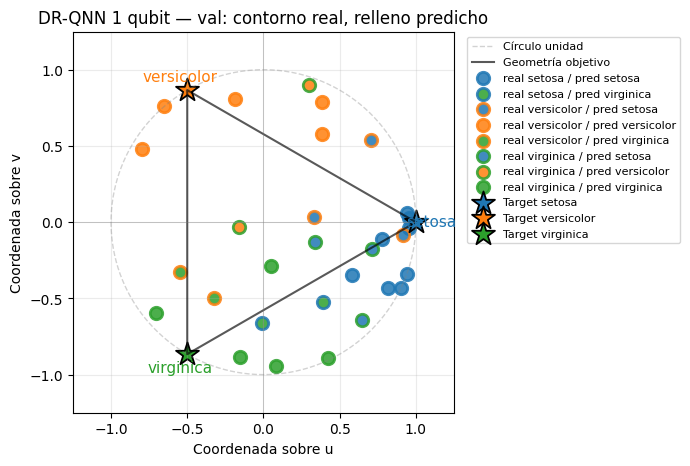

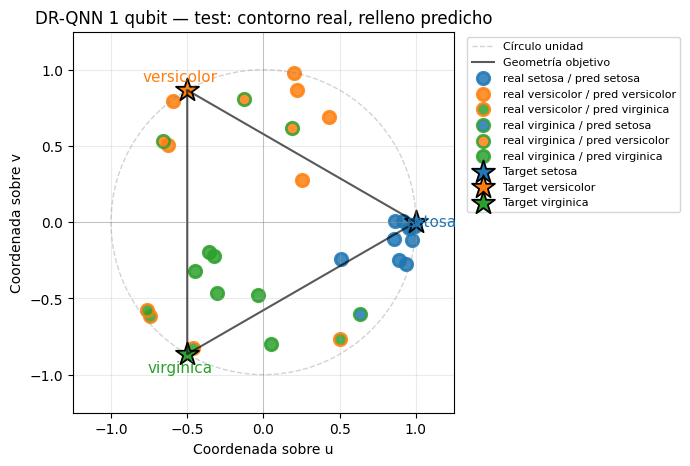

In [44]:
def project_to_target_plane(points_3d):
    coord_u = points_3d @ u
    coord_v = points_3d @ v
    return np.stack([coord_u, coord_v], axis=1)


targets_2d = project_to_target_plane(BLOCH_TARGETS_np)

bloch_train_2d = project_to_target_plane(bloch_train)
bloch_val_2d   = project_to_target_plane(bloch_val)
bloch_test_2d  = project_to_target_plane(bloch_test)


def plot_bloch_2d_true_pred(bloch_points_2d, y_true, y_pred, split_name):

    plt.figure(figsize=(7, 7))

    # Círculo unidad proyectado
    angle = np.linspace(0, 2 * np.pi, 300)

    plt.plot(
        np.cos(angle),
        np.sin(angle),
        linestyle="--",
        linewidth=1,
        alpha=0.35,
        color="gray",
        label="Círculo unidad"
    )

    # Triángulo objetivo
    triangle = np.vstack([targets_2d, targets_2d[0]])

    plt.plot(
        triangle[:, 0],
        triangle[:, 1],
        color="black",
        linewidth=1.5,
        alpha=0.65,
        label="Geometría objetivo"
    )

    # Puntos: borde = real, relleno = predicho
    for true_id in range(N_CLASES):
        for pred_id in range(N_CLASES):

            mask = (y_true == true_id) & (y_pred == pred_id)

            if np.sum(mask) == 0:
                continue

            plt.scatter(
                bloch_points_2d[mask, 0],
                bloch_points_2d[mask, 1],
                s=80,
                facecolors=class_colors[pred_id],
                edgecolors=class_colors[true_id],
                linewidth=2.0,
                alpha=0.85,
                label=f"real {NOMBRES_CLASES[true_id]} / pred {NOMBRES_CLASES[pred_id]}"
            )

    # Targets
    for clase_id, nombre in enumerate(NOMBRES_CLASES):

        plt.scatter(
            targets_2d[clase_id, 0],
            targets_2d[clase_id, 1],
            s=300,
            marker="*",
            color=class_colors[clase_id],
            edgecolor="black",
            linewidth=1.3,
            label=f"Target {nombre}"
        )

        plt.text(
            targets_2d[clase_id, 0] * 1.10,
            targets_2d[clase_id, 1] * 1.10,
            nombre,
            fontsize=11,
            color=class_colors[clase_id],
            ha="center",
            va="center"
        )

    plt.axhline(0, color="gray", linewidth=0.7, alpha=0.4)
    plt.axvline(0, color="gray", linewidth=0.7, alpha=0.4)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlim(-1.25, 1.25)
    plt.ylim(-1.25, 1.25)

    plt.xlabel("Coordenada sobre u")
    plt.ylabel("Coordenada sobre v")
    plt.title(f"DR-QNN 1 qubit — {split_name}: contorno real, relleno predicho")

    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_bloch_2d_true_pred(bloch_train_2d, y_train, y_train_pred, "train")
plot_bloch_2d_true_pred(bloch_val_2d,   y_val,   y_val_pred,   "val")
plot_bloch_2d_true_pred(bloch_test_2d,  y_test,  y_test_pred,  "test")

**Qubit interactivo**

In [54]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "iframe"

In [53]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "iframe"

def plot_bloch_3d_interactive(bloch_points, y_true, y_pred, split_name):

    fig = go.Figure()

    # Esfera transparente
    phi = np.linspace(0, 2*np.pi, 80)
    theta_s = np.linspace(0, np.pi, 40)

    xs = np.outer(np.cos(phi), np.sin(theta_s))
    ys = np.outer(np.sin(phi), np.sin(theta_s))
    zs = np.outer(np.ones_like(phi), np.cos(theta_s))

    fig.add_trace(go.Surface(
        x=xs, y=ys, z=zs,
        opacity=0.12,
        showscale=False,
        name="Esfera de Bloch"
    ))

    # Datos: color = predicho, símbolo = clase real
    symbols = {
        0: "circle",
        1: "diamond",
        2: "square"
    }

    plotly_colors = {
        0: "blue",
        1: "orange",
        2: "green"
    }

    for true_id in range(N_CLASES):
        for pred_id in range(N_CLASES):

            mask = (y_true == true_id) & (y_pred == pred_id)

            if np.sum(mask) == 0:
                continue

            fig.add_trace(go.Scatter3d(
                x=bloch_points[mask, 0],
                y=bloch_points[mask, 1],
                z=bloch_points[mask, 2],
                mode="markers",
                marker=dict(
                    size=6,
                    color=plotly_colors[pred_id],
                    symbol=symbols[true_id],
                    line=dict(
                        color=plotly_colors[true_id],
                        width=4
                    )
                ),
                name=f"real {NOMBRES_CLASES[true_id]} / pred {NOMBRES_CLASES[pred_id]}"
            ))

    # Targets
    for clase_id, nombre in enumerate(NOMBRES_CLASES):

        target = BLOCH_TARGETS_np[clase_id]

        fig.add_trace(go.Scatter3d(
            x=[target[0]],
            y=[target[1]],
            z=[target[2]],
            mode="markers+text",
            marker=dict(
                size=12,
                color=plotly_colors[clase_id],
                symbol="diamond",
                line=dict(color="black", width=4)
            ),
            text=[f"Target {nombre}"],
            textposition="top center",
            name=f"Target {nombre}"
        ))

    # Ejes
    fig.add_trace(go.Scatter3d(
        x=[0, 1.15], y=[0, 0], z=[0, 0],
        mode="lines+text",
        line=dict(width=5),
        text=["", "X"],
        name="Eje X"
    ))

    fig.add_trace(go.Scatter3d(
        x=[0, 0], y=[0, 1.15], z=[0, 0],
        mode="lines+text",
        line=dict(width=5),
        text=["", "Y"],
        name="Eje Y"
    ))

    fig.add_trace(go.Scatter3d(
        x=[0, 0], y=[0, 0], z=[0, 1.15],
        mode="lines+text",
        line=dict(width=5),
        text=["", "Z"],
        name="Eje Z"
    ))

    fig.update_layout(
        title=f"DR-QNN 1 qubit — {split_name} interactivo",
        width=900,
        height=750,
        scene=dict(
            xaxis=dict(title="<X>", range=[-1.2, 1.2]),
            yaxis=dict(title="<Y>", range=[-1.2, 1.2]),
            zaxis=dict(title="<Z>", range=[-1.2, 1.2]),
            aspectmode="cube"
        ),
        legend=dict(
            x=1.02,
            y=1.0
        )
    )

    fig.show(renderer="iframe")


plot_bloch_3d_interactive(bloch_train, y_train, y_train_pred, "train")
plot_bloch_3d_interactive(bloch_val,   y_val,   y_val_pred,   "val")
plot_bloch_3d_interactive(bloch_test,  y_test,  y_test_pred,  "test")